In [3]:
from google.colab import files

uploaded = files.upload()

Saving WineQT.csv to WineQT (1).csv


#1-Exploração dos Dados

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("WineQT.csv")

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [7]:
df.shape

(1143, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [10]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [11]:
df["quality"].value_counts().sort_index()

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


#2-Visualização Dos dados

In [12]:
# Criando a variável alvo do projeto
# Regra definida pela FIAP:
# quality >= 7 -> vinho de alta qualidade (1)
# quality < 7 -> vinho de baixa/média qualidade (0)

df['high_quality'] = (df['quality'] >= 7).astype(int)

# Verificando se a coluna foi criada corretamente
df[['quality', 'high_quality']].head()

,quality,high_quality
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [13]:
# Verificando a quantidade de vinhos em cada classe

df['high_quality'].value_counts()

,count
high_quality,
0,984
1,159


In [14]:
# Verificando o percentual de cada classe

df['high_quality'].value_counts(normalize=True) * 100

,proportion
high_quality,
0,86.089239
1,13.910761


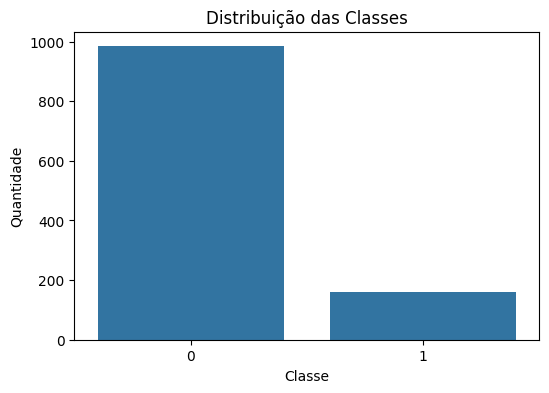

In [15]:
# Visualizando o balanceamento através de gráfico

plt.figure(figsize=(6,4))

sns.countplot(
    x='high_quality',
    data=df
)

plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

plt.show()

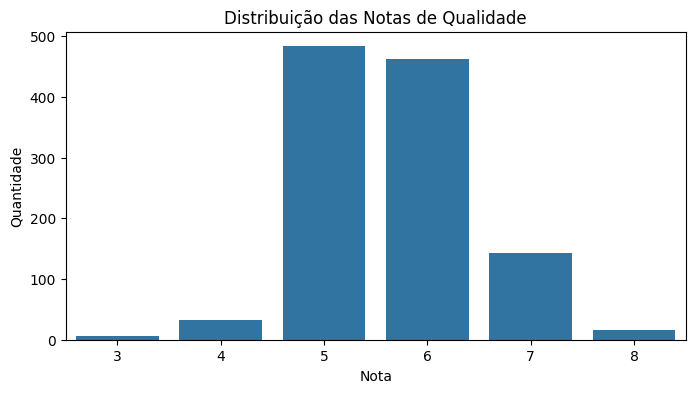

In [16]:
# Analisando como as notas de qualidade estão distribuídas no dataset

plt.figure(figsize=(8,4))

sns.countplot(
    x='quality',
    data=df
)

plt.title('Distribuição das Notas de Qualidade')
plt.xlabel('Nota')
plt.ylabel('Quantidade')

plt.show()

In [17]:
# Comparando a média das variáveis
# entre vinhos premium e não premium

df.groupby('high_quality').mean(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
high_quality,,,,,,,,,,,,,
0,8.224593,0.553318,0.248516,2.497205,0.088908,15.846037,47.408028,0.996845,3.315630,0.643465,10.266582,5.423780,801.396341
1,8.846541,0.395314,0.391195,2.748428,0.074711,14.188679,36.672956,0.996019,3.282453,0.745849,11.528407,7.100629,827.081761


In [18]:
# Calculando a correlação das variáveis
# com a nota de qualidade do vinho

correlacoes = (
    df.corr(numeric_only=True)['quality']
      .sort_values(ascending=False)
)

correlacoes

,quality
quality,1.000000
high_quality,0.720433
alcohol,0.484866
sulphates,0.257710
citric acid,0.240821
fixed acidity,0.121970
Id,0.069708
residual sugar,0.022002
pH,-0.052453
free sulfur dioxide,-0.063260


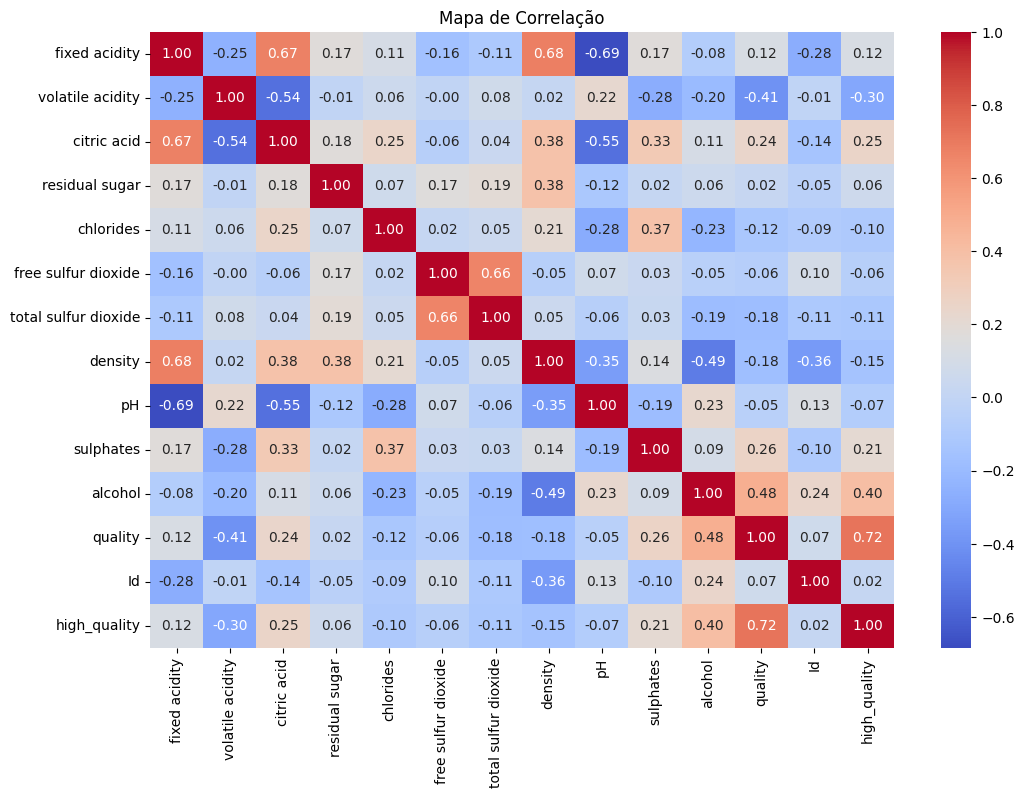

In [19]:
# Visualizando as correlações entre todas as variáveis

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de Correlação')

plt.show()

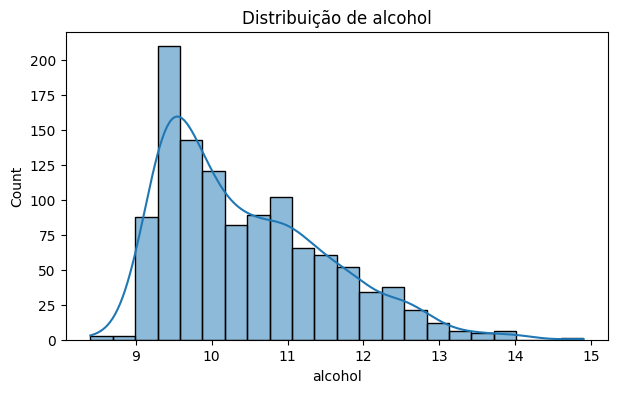

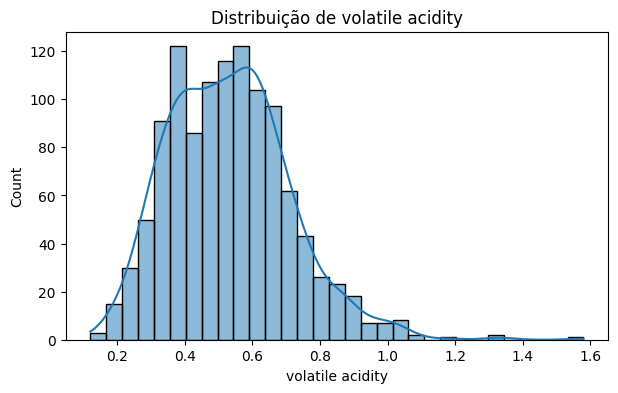

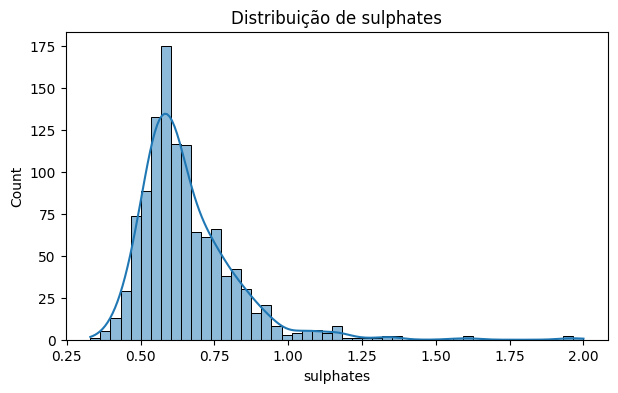

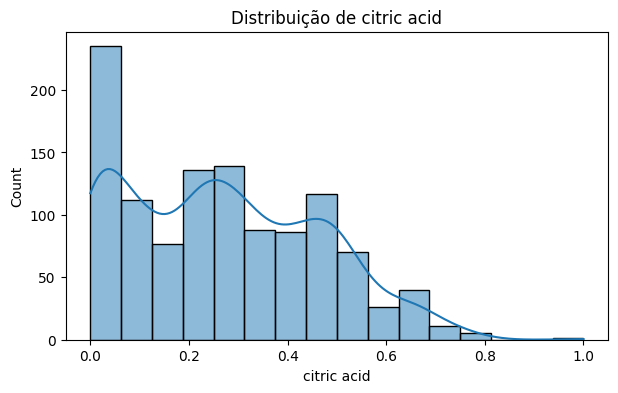

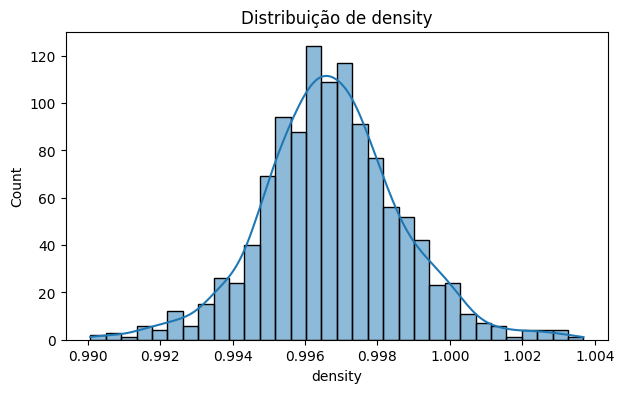

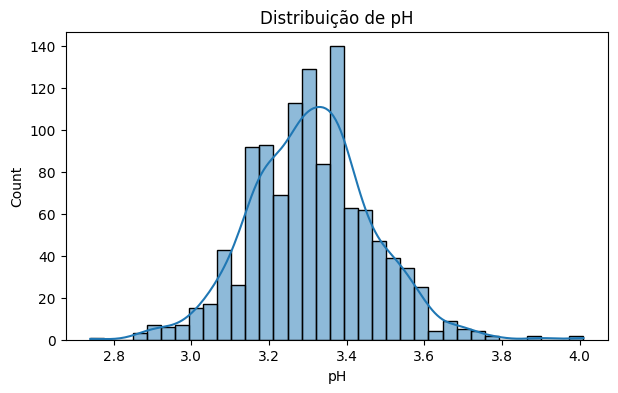

In [20]:
# Lista das variáveis mais relevantes para análise

variaveis = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'density',
    'pH'
]

# Gerando histogramas para entender a distribuição dos dados

for coluna in variaveis:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[coluna],
        kde=True
    )

    plt.title(f'Distribuição de {coluna}')

    plt.show()

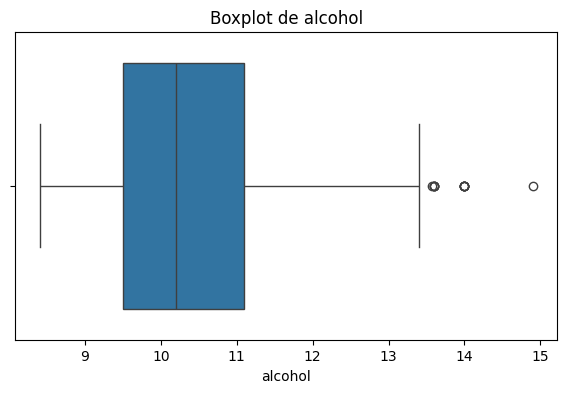

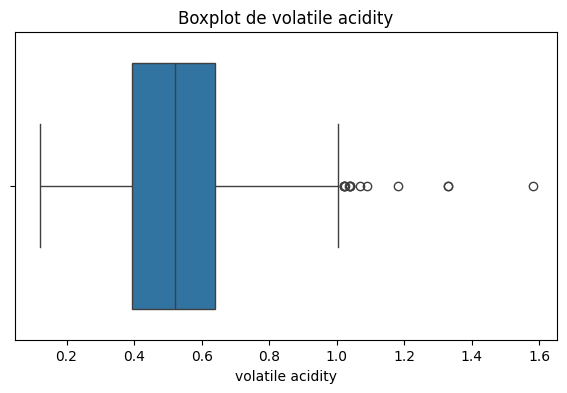

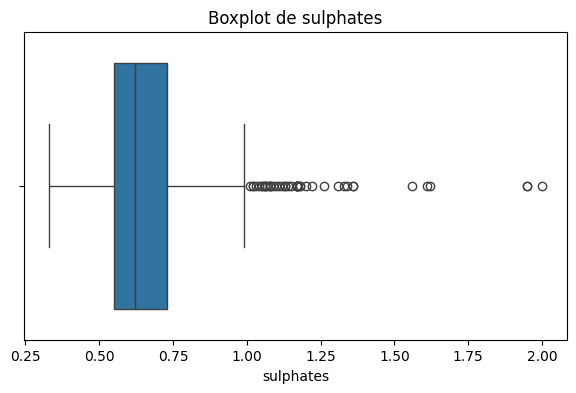

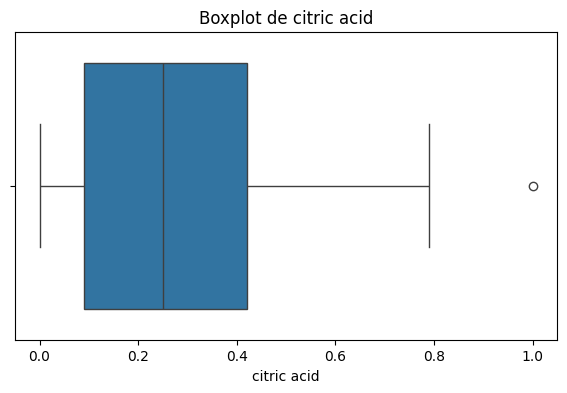

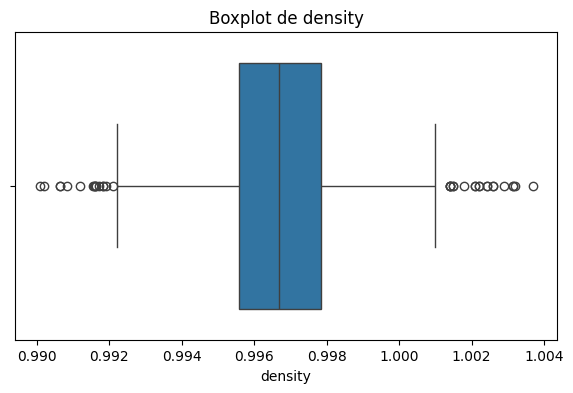

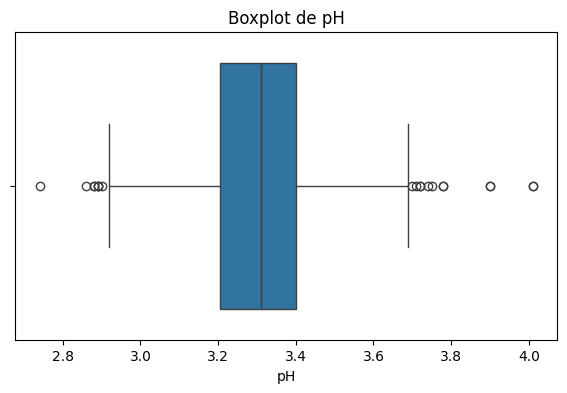

In [21]:
# Utilizando boxplots para identificar possíveis valores extremos

for coluna in variaveis:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=df[coluna]
    )

    plt.title(f'Boxplot de {coluna}')

    plt.show()

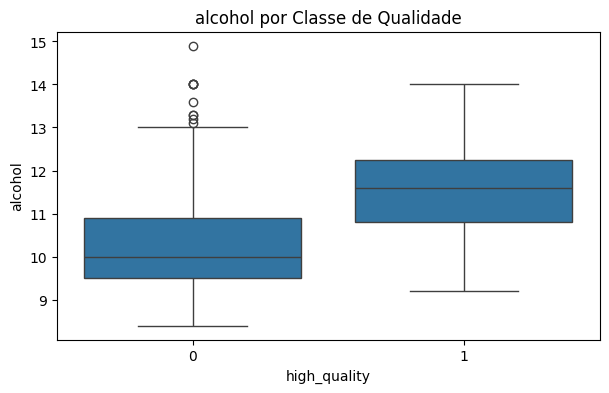

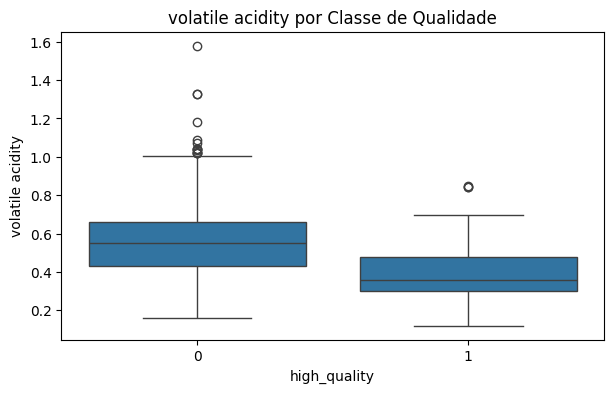

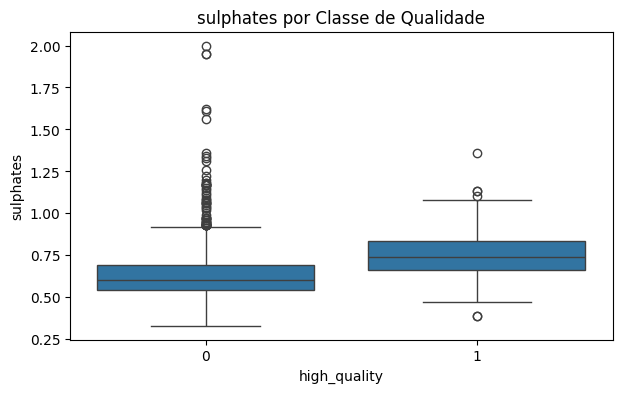

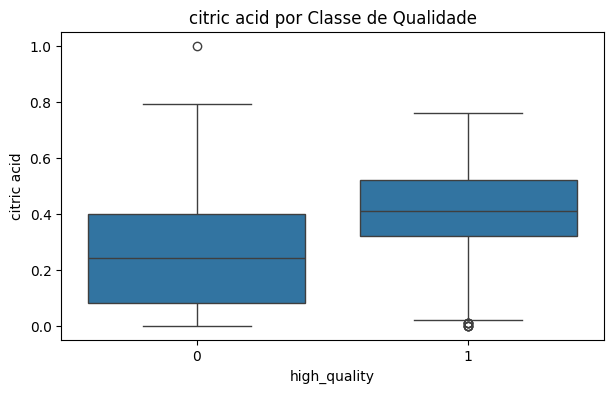

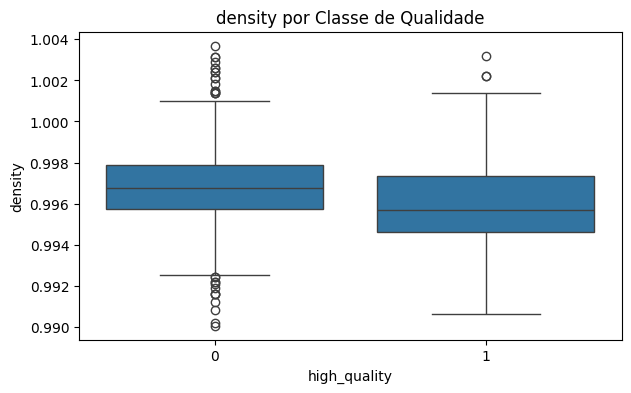

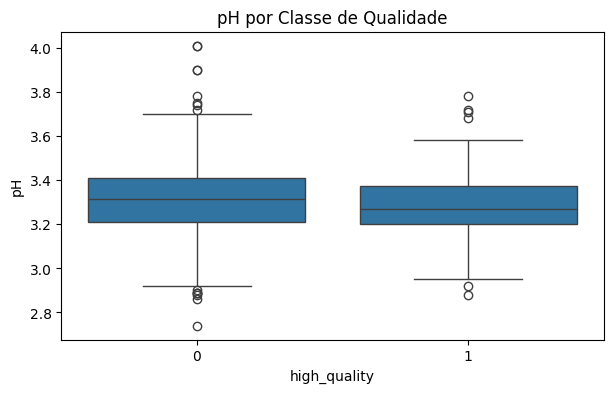

In [22]:
# Comparando o comportamento das variáveis
# entre vinhos de alta qualidade e demais vinhos

for coluna in variaveis:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x='high_quality',
        y=coluna,
        data=df
    )

    plt.title(f'{coluna} por Classe de Qualidade')

    plt.show()

### Principais Insights

- O teor alcoólico apresentou correlação positiva com a qualidade.
- A acidez volátil apresentou correlação negativa.
- As demais variáveis mostraram correlações fracas ou moderadas.

##3-Pré-processamento dos Dados

In [23]:
# Verificando se existem valores faltantes

df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Foi realizada a verificação de valores ausentes no dataset. Não foram identificados valores nulos, não sendo necessário tratamento adicional nesta etapa.

Nesta etapa serão realizadas as transformações necessárias para preparar os dados para o treinamento dos modelos de Machine Learning.

A ideia inclui a verificação de valores faltantes, separação das variáveis explicativas e da variável alvo, divisão dos dados em conjuntos de treino e teste e padronização das variáveis numéricas.

Para o treinamento dos modelos é necessário separar as variáveis explicativas (features) da variável alvo (target).

As variáveis explicativas representam as características físico-químicas dos vinhos, enquanto a variável alvo representa a classificação de qualidade definida para o projeto.

In [24]:
# Separando as variáveis explicativas (X)
# da variável alvo (y)
# A coluna Id foi removida por ser apenas um identificador,
# não representando uma característica físico-química do vinho.

X = df.drop(columns=['Id', 'quality', 'high_quality'])

y = df['high_quality']

In [25]:
# Verificando as dimensões dos conjuntos

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (1143, 11)
Dimensão de y: (1143,)


As variáveis explicativas foram armazenadas em X e a variável alvo em y.

A coluna original quality foi removida das variáveis de entrada para evitar vazamento de informação durante o treinamento dos modelos.

Os dados foram divididos em conjuntos de treinamento e teste.

O conjunto de treinamento será utilizado para ensinar os modelos de Machine Learning, enquanto o conjunto de teste será utilizado para avaliar sua capacidade de generalização em dados nunca vistos anteriormente.

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
# Dividindo os dados
# 80% para treino
# 20% para teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
# Conferindo o tamanho dos conjuntos

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (914, 11)
X_test: (229, 11)
y_train: (914,)
y_test: (229,)


A base foi dividida em 80% para treinamento e 20% para teste.

Essa estratégia permite avaliar o desempenho dos modelos em registros que não participaram do processo de aprendizado.

As variáveis do dataset apresentam escalas diferentes.

Para evitar que variáveis com valores maiores exerçam influência desproporcional nos algoritmos, foi aplicada a técnica de padronização utilizando o StandardScaler.

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
# Criando o objeto responsável pela padronização

scaler = StandardScaler()

In [31]:
# Ajustando e transformando os dados de treino

X_train_scaled = scaler.fit_transform(X_train)

# Aplicando a mesma transformação aos dados de teste

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(914, 11)
(229, 11)


In [32]:
# Visualizando as primeiras linhas padronizadas

X_train_scaled[:5]

array([[ 0.1426802 , -1.40273053,  1.5096933 , -0.55102394,  0.11651554,
         1.88559834,  1.79122276,  0.11355786, -0.09314751,  0.56821234,
         0.05661327],
       [ 0.96843134, -1.17920341,  1.5096933 , -0.39776844, -0.28423884,
        -1.24188154, -1.18572018, -0.7017669 , -1.07474038,  0.4477703 ,
         0.89445566],
       [ 0.3786091 , -1.23508519,  0.4833938 ,  0.06199805, -0.64280855,
        -0.55774532, -0.21429669, -0.55542656,  0.56124774,  0.20688622,
         1.26683005],
       [-0.97798208,  1.95017634, -1.1586854 , -0.24451294, -0.43188519,
        -0.36227782, -0.80968528, -0.16866994,  1.41196156, -0.57598704,
        -0.50194833],
       [-0.38815983, -0.6203856 , -0.08107092,  1.0581588 ,  0.36962357,
         1.20146211,  1.38385162,  0.6048433 , -1.07474038, -0.51576602,
        -1.24669712]])

Após a padronização, todas as variáveis passaram a possuir escalas comparáveis.


## Conclusão da etapa anterior

Ao final do pré-processamento, os dados encontram-se preparados para a construção dos modelos de Machine Learning.

As principais atividades realizadas foram:

- Verificação de valores faltantes;
- Separação entre variáveis explicativas e variável alvo;
- Divisão dos dados em conjuntos de treino e teste;
- Padronização das variáveis numéricas.

Com isso, a base está pronta para a etapa de modelagem e treinamento dos algoritmos de classificação.

#**Desenvolvimento dos Modelos**

Na etapa seguinte serão treinados dois modelos de classificação com o objetivo


de prever se um vinho pertence à classe de alta qualidade ou baixa/média

qualidade.

Foram escolhidos dois algoritmos distintos:

- Regressão Logística: modelo linear, simples e interpretável.
- Random Forest: modelo baseado em árvores de decisão, capaz de capturar relações mais complexas entre as variáveis.

A comparação entre os modelos permitirá avaliar qual abordagem apresenta melhor desempenho para o problema proposto.

#Modelo 1 para o Challenge — Regressão Logística

A Regressão Logística é o primeiro modelo utilizado

Fato a ser considerado:

- 0: vinho de baixa/média qualidade
- 1: vinho de alta qualidade

Como esse modelo é sensível à escala das variáveis, será utilizada a base padronizada.

In [33]:
# Importando o modelo de Regressão Logística

from sklearn.linear_model import LogisticRegression

In [34]:
# Criando o modelo

modelo_logistico = LogisticRegression(random_state=42)

In [35]:
# Treinando o modelo com os dados de treino padronizados

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [36]:
import numpy as np
# Gerando previsões para os dados de teste
X_test_scaled = scaler.transform(X_test)
y_pred_logistico = modelo_logistico.predict(X_test_scaled)

In [37]:
# Gerando probabilidades para cálculo da curva ROC e AUC

y_proba_logistico = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

### Insight

O modelo de Regressão Logística foi treinado utilizando os dados de treino padronizados.


## Modelo 2 para o Challenge — Random Forest


In [38]:
# Importando o modelo Random Forest

from sklearn.ensemble import RandomForestClassifier

In [39]:
# Criando o modelo Random Forest

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [40]:
# Treinando o modelo com os dados de treino

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
# Gerando previsões para os dados de teste

y_pred_rf = modelo_rf.predict(X_test)

In [42]:
# Gerando probabilidades para cálculo da curva ROC e AUC

y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

### Insight

O modelo Random Forest foi treinado utilizando os dados de treino originais.

Após o treinamento, foram geradas previsões para o conjunto de teste, permitindo sua comparação com o modelo de Regressão Logística.

# Avaliação dos Modelos

Após o treinamento dos modelos, nessa etapa será realizada a avaliação de desempenho utilizando métricas de classificação.

O objetivo desta etapa é comparar os modelos treinados e identificar qual deles apresenta melhor capacidade de prever a qualidade dos vinhos.

As métricas utilizadas foram:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC AUC

Também serão analisadas as matrizes de confusão para melhor interpretação dos resultados.

#**Primeira Avaliação: Modelo de Regressão Logística**

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_log = accuracy_score(y_test, y_pred_logistico)

precision_log = precision_score(y_test, y_pred_logistico)

recall_log = recall_score(y_test, y_pred_logistico)

f1_log = f1_score(y_test, y_pred_logistico)

print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-Score:", f1_log)

Accuracy: 0.9082969432314411
Precision: 0.6521739130434783
Recall: 0.5357142857142857
F1-Score: 0.5882352941176471


### Resultado modelo Regressão Logística

As métricas acima representam o desempenho da Regressão Logística no conjunto de teste.

Os resultados serão comparados posteriormente com o modelo Random Forest.

#**Avaliação Modelo Random Forest**

In [44]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-Score:", f1_rf)

Accuracy: 0.9170305676855895
Precision: 0.6956521739130435
Recall: 0.5714285714285714
F1-Score: 0.6274509803921569


### Resultado modelo Random Forest

As métricas acima representam o desempenho da Random Forest no conjunto de teste.



#**Analisando as métricas de cada Modelo proposto**

Modelo Regressão Logística

In [45]:
from sklearn.metrics import classification_report

print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_logistico))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.65      0.54      0.59        28

    accuracy                           0.91       229
   macro avg       0.79      0.75      0.77       229
weighted avg       0.90      0.91      0.90       229



Modelo Random Forest

In [46]:
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       201
           1       0.70      0.57      0.63        28

    accuracy                           0.92       229
   macro avg       0.82      0.77      0.79       229
weighted avg       0.91      0.92      0.91       229



#**Analisando Matriz Confusão**

Modelo Regressão Logística

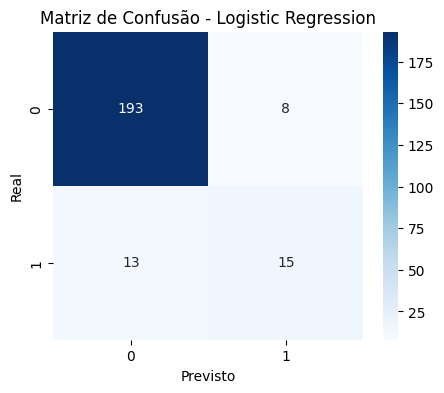

In [47]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_logistico)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Logistic Regression')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

Modelo Random Forest

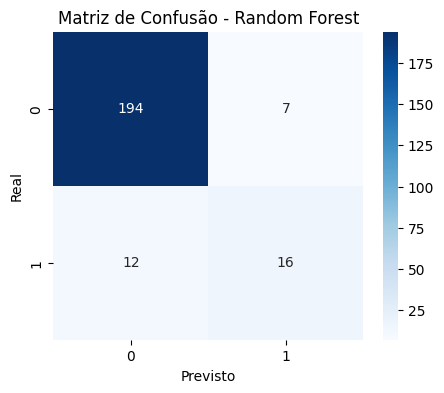

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

#**Analisando AUC Score**

Foco na capacidade de os modelos separarem vinhos comuns e vinhos de alta qualidade

Modelo Regressão Logística

In [49]:
from sklearn.metrics import roc_auc_score

auc_log = roc_auc_score(y_test, y_proba_logistico)

print("AUC - Logistic Regression:", auc_log)

AUC - Logistic Regression: 0.9010305614783227


Modelo Random Forest

In [50]:
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("AUC - Random Forest:", auc_rf)

AUC - Random Forest: 0.9591329068941009


Curva ROC de ambos os modelos no mesmo gráfico:

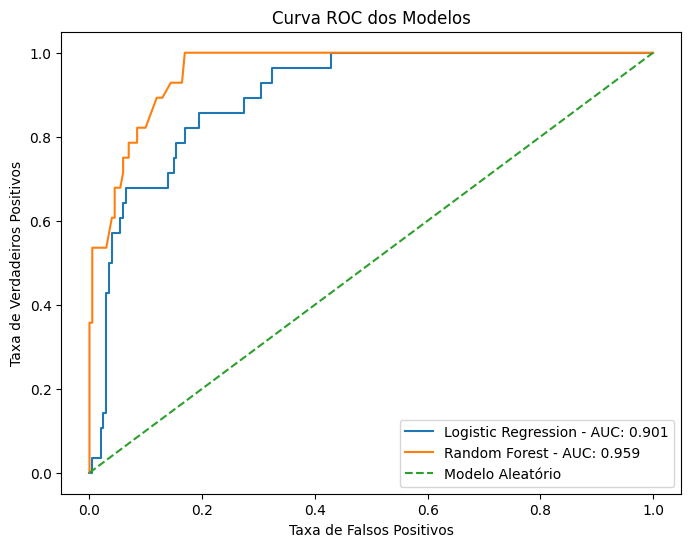

In [51]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Curva ROC - Regressão Logística
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_logistico)

# Curva ROC - Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression - AUC: {auc_log:.3f}')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest - AUC: {auc_rf:.3f}')

plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo Aleatório')

plt.title('Curva ROC dos Modelos')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend()
plt.show()

Tabela Final

In [52]:
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_log, accuracy_rf],
    'Precision': [precision_log, precision_rf],
    'Recall': [recall_log, recall_rf],
    'F1-Score': [f1_log, f1_rf],
    'AUC': [auc_log, auc_rf]
})

comparacao_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.908297,0.652174,0.535714,0.588235,0.901031
1,Random Forest,0.917031,0.695652,0.571429,0.627451,0.959133


### Análise Comparativa

O modelo Random Forest apresentou desempenho superior em todas as métricas avaliadas. Apesar da diferença moderada em Accuracy, o modelo também obteve melhores valores de Precision, Recall, F1-Score e AUC, indicando maior capacidade de separar vinhos de alta qualidade dos demais. Dessa forma, o Random Forest foi considerado o modelo mais adequado entre os avaliados.

# Interpretação dos Resultados

## Comparação dos Modelos

Foram avaliados dois algoritmos de classificação:

- Regressão Logística
- Random Forest

Os resultados demonstraram desempenho superior do modelo Random Forest em todas as métricas analisadas.

A Regressão Logística apresentou Accuracy de aproximadamente 90,8% e AUC de 0,90.

Já o Random Forest atingiu Accuracy de aproximadamente 91,7% e AUC de 0,96, demonstrando maior capacidade de distinguir vinhos de alta qualidade dos demais.

## Interpretação das Métricas

Apesar de ambos os modelos apresentarem desempenho satisfatório, o Random Forest obteve melhores resultados em Precision, Recall e F1-Score.

Esse comportamento é especialmente relevante devido ao desbalanceamento existente entre as classes do problema.

O F1-Score superior indica melhor equilíbrio entre a capacidade de identificar vinhos de alta qualidade e a redução de classificações incorretas.

## Importância das Variáveis

Como o modelo Random Forest apresentou o melhor desempenho geral, foi realizada uma análise da importância das variáveis utilizadas pelo modelo.

Essa análise permite identificar quais características físico-químicas tiveram maior influência na classificação dos vinhos.

In [53]:
import pandas as pd

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)

importancias

,Variavel,Importancia
10,alcohol,0.163982
9,sulphates,0.120266
1,volatile acidity,0.112545
7,density,0.103119
2,citric acid,0.086050
0,fixed acidity,0.077569
4,chlorides,0.073959
6,total sulfur dioxide,0.072437
8,pH,0.067294
3,residual sugar,0.065264


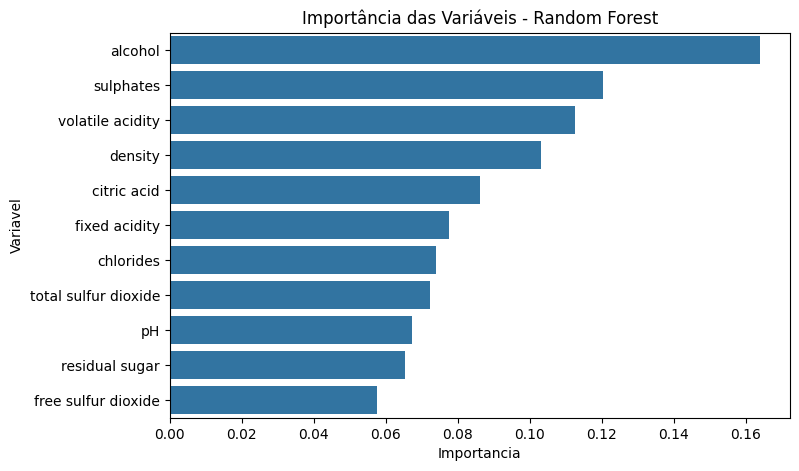

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importancias,
    x='Importancia',
    y='Variavel'
)

plt.title('Importância das Variáveis - Random Forest')

plt.show()

## Principais Variáveis

A análise de importância das variáveis permite identificar quais características físico-químicas exercem maior influência na classificação da qualidade dos vinhos.

Entre as variáveis mais relevantes destacam-se aquelas relacionadas ao teor alcoólico, composição química e acidez, fatores que também apresentaram associações importantes durante a análise exploratória dos dados.

## Conclusão Final

O objetivo do projeto foi desenvolver modelos de Machine Learning capazes de classificar vinhos em duas categorias:

- Baixa/Média Qualidade
- Alta Qualidade

Para isso, a variável `quality` foi transformada em uma variável binária, considerando vinhos com nota igual ou superior a 7 como vinhos de alta qualidade.

Foram treinados e avaliados dois modelos de classificação: Regressão Logística e Random Forest.

Com base nas métricas avaliadas, o modelo Random Forest apresentou o melhor desempenho geral, superando a Regressão Logística em Accuracy, Precision, Recall, F1-Score e AUC.

Apesar dos bons resultados gerais, o desbalanceamento entre as classes deve ser considerado na interpretação dos resultados, especialmente porque a classe de vinhos de alta qualidade possui menor representatividade no dataset.

De forma geral, os resultados demonstram que as características físico-químicas dos vinhos possuem capacidade preditiva relevante para auxiliar na classificação da qualidade, podendo apoiar processos de controle, padronização e tomada de decisão na indústria vitivinícola.

In [55]:
from sklearn.metrics import accuracy_score

# Previsões no conjunto de treino
train_pred = modelo_rf.predict(X_train)

# Accuracy no treino e no teste
print("Accuracy Treino:", accuracy_score(y_train, train_pred))
print("Accuracy Teste :", accuracy_score(y_test, y_pred_rf))

Accuracy Treino: 1.0
Accuracy Teste : 0.9170305676855895


### Observação

Foi realizada uma verificação adicional comparando a acurácia do modelo Random Forest nos conjuntos de treinamento e teste. O modelo atingiu 100% de acurácia no treinamento e aproximadamente 91,7% no teste, indicando um possível indício de overfitting. No entanto, o desempenho no conjunto de teste permaneceu elevado, sugerindo boa capacidade de generalização. Como o objetivo deste projeto foi comparar e interpretar modelos de classificação, conforme proposto pelo desafio, não foi realizada otimização de hiperparâmetros nesta etapa.